In [1]:
import numpy as np
from ase import Atoms
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from mace.calculators import mace_mp
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse_fig5(path):
    lines = open(path).read().splitlines()
    text = open(path).read().split()
    cell = np.array([float(x) for x in text[:9]]).reshape(3, 3)
    symbols, scaled = [], []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 6 and parts[3].isdigit() and parts[4].isdigit():
            typ = int(parts[3])
            if typ == 0:
                continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ])
                scaled.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
atoms = parse_fig5("Al9Co2Ni2-coords.txt")
atoms.calc = calc
BFGS(FrechetCellFilter(atoms), logfile=None).run(fmax=0.001)
print(f"Relaxed: {len(atoms)} atoms, {dict(Counter(atoms.get_chemical_symbols()))}")
print(f"Max residual force: {np.sqrt((atoms.get_forces()**2).sum(axis=1)).max():.5f} eV/A")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Relaxed: 26 atoms, {'Al': 18, 'Ni': 3, 'Co': 5}
Max residual force: 0.00083 eV/A


In [2]:
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units
import time

md_atoms = atoms.copy()
md_atoms.calc = calc

T = 300  # K — matches Mihalkovic's 300 K MD for this exact system (Fig 2 caption)

MaxwellBoltzmannDistribution(md_atoms, temperature_K=T)
Stationary(md_atoms)   # zero net momentum -> no whole-crystal drift

timestep = 2.0 * units.fs
friction = 0.01 / units.fs
dyn = Langevin(md_atoms, timestep, temperature_K=T, friction=friction)

temps = []
def log_T():
    ekin = md_atoms.get_kinetic_energy() / len(md_atoms)
    temps.append(ekin / (1.5 * units.kB))
dyn.attach(log_T, interval=50)

print(f"Equilibrating {len(md_atoms)} atoms at {T} K for 10 ps...")
t0 = time.time()
dyn.run(5000)   # 5000 x 2fs = 10 ps
print(f"Done in {time.time()-t0:.0f}s")

temps = np.array(temps)
sh = temps[len(temps)//2:]
print(f"\nMean T (2nd half): {sh.mean():.1f} K (target {T})")
print(f"Std dev: {sh.std():.1f} K")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Equilibrating 26 atoms at 300 K for 10 ps...
Done in 1381s

Mean T (2nd half): 295.3 K (target 300)
Std dev: 56.3 K


In [3]:
from ase.md.verlet import VelocityVerlet
import numpy as np, time

# NVE production - thermostat OFF, continues from the equilibrated structure
dyn_nve = VelocityVerlet(md_atoms, timestep)   # same 2 fs timestep

# storage for velocities (and energy, to check NVE conservation)
velocities = []
energies = []
sample_every = 2          # record every 2 steps = every 4 fs
n_steps = 5000            # 5000 x 2fs = 10 ps production (short, just to prove the pipeline)

def record():
    velocities.append(md_atoms.get_velocities().copy())
    energies.append(md_atoms.get_total_energy())

dyn_nve.attach(record, interval=sample_every)

print(f"NVE production: {n_steps} steps ({n_steps*2/1000:.0f} ps), sampling every {sample_every*2} fs...")
t0 = time.time()
dyn_nve.run(n_steps)
print(f"Done in {time.time()-t0:.0f}s")

velocities = np.array(velocities)   # shape: (n_samples, n_atoms, 3)
energies = np.array(energies)
print(f"\nStored velocities: {velocities.shape}  (samples, atoms, xyz)")

# check NVE energy conservation (should be nearly flat)
drift = (energies.max() - energies.min()) / len(md_atoms) * 1000  # meV/atom
print(f"Total energy drift over run: {drift:.3f} meV/atom  (small = good NVE)")
print(f"Sampling interval: {sample_every*2} fs -> max resolvable frequency ~{1000/(2*sample_every*2)*4.1357:.0f} meV")

NVE production: 5000 steps (10 ps), sampling every 4 fs...
Done in 1353s

Stored velocities: (2501, 26, 3)  (samples, atoms, xyz)
Total energy drift over run: 0.105 meV/atom  (small = good NVE)
Sampling interval: 4 fs -> max resolvable frequency ~517 meV


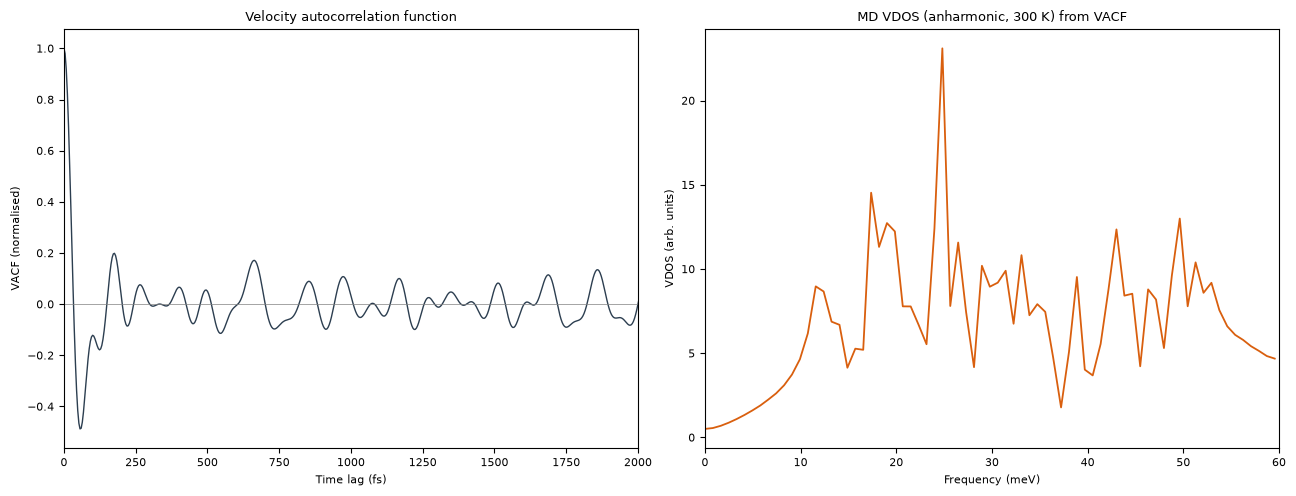

VACF computed over 1250 lags (5000 fs)
Frequency resolution: 0.83 meV


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# velocities shape: (n_samples, n_atoms, 3)
# --- compute the velocity autocorrelation function (VACF) ---
# average over atoms and time origins, for each lag
n_samples = velocities.shape[0]
max_lag = n_samples // 2      # use half the trajectory as max correlation lag

# mass-weight the VACF (heavier atoms weighted more) - standard for VDOS
from ase.data import atomic_masses, atomic_numbers
masses = np.array([atomic_masses[atomic_numbers[s]] for s in md_atoms.get_chemical_symbols()])

vacf = np.zeros(max_lag)
for lag in range(max_lag):
    # dot product of v(t+lag).v(t), summed over xyz, mass-weighted, averaged over atoms & origins
    dots = np.sum(velocities[:n_samples-lag] * velocities[lag:], axis=2)  # (origins, atoms)
    dots = dots * masses[None, :]        # mass weight
    vacf[lag] = dots.mean()
vacf /= vacf[0]      # normalise so VACF(0) = 1

# --- Fourier transform the VACF -> VDOS ---
dt = sample_every * 2 * 1e-15      # sampling interval in seconds (4 fs)
window = np.hanning(2 * len(vacf))[len(vacf):]   # half-Hann window
vacf_windowed = vacf * window

spectrum = np.abs(np.fft.rfft(vacf_windowed))
freqs_Hz = np.fft.rfftfreq(len(vacf_windowed), d=dt)   # SAME length as spectrum
freqs_meV = (freqs_Hz / 1e12) * 4.13567                # Hz -> meV
# correct conversion: 1 THz = 4.13567 meV; freqs_Hz in Hz -> THz is /1e12
freqs_meV = (freqs_Hz / 1e12) * 4.13567

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# left: the VACF itself
t_fs = np.arange(max_lag) * sample_every * 2
axes[0].plot(t_fs, vacf, color="#2c3e50", lw=1)
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_xlabel("Time lag (fs)"); axes[0].set_ylabel("VACF (normalised)")
axes[0].set_title("Velocity autocorrelation function")
axes[0].set_xlim(0, 2000)

# right: the VDOS
mask = (freqs_meV >= 0) & (freqs_meV <= 60)
axes[1].plot(freqs_meV[mask], spectrum[mask], color="#d95f0e", lw=1.3)
axes[1].set_xlabel("Frequency (meV)"); axes[1].set_ylabel("VDOS (arb. units)")
axes[1].set_title("MD VDOS (anharmonic, 300 K) from VACF")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.savefig("o2_md_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"VACF computed over {max_lag} lags ({max_lag*4} fs)")
print(f"Frequency resolution: {freqs_meV[1]-freqs_meV[0]:.2f} meV")

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_2852/2547366675.py:6: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  hd = ph.get_total_dos_dict()


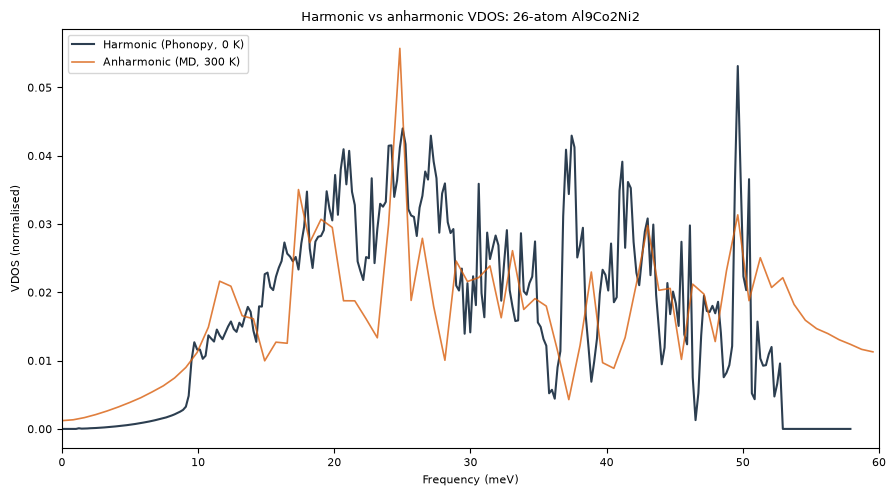

In [6]:
import phonopy

# reload harmonic VDOS for the 26-atom
ph = phonopy.load("o2_phonon_26atom.yaml")
ph.run_mesh([20,20,20]); ph.run_total_dos(freq_pitch=0.05)
hd = ph.get_total_dos_dict()
h_f = hd["frequency_points"] * 4.13567
h_dos = hd["total_dos"]

# normalise both to unit area (so shapes are comparable)
mask_md = (freqs_meV >= 0) & (freqs_meV <= 60)
md_f, md_d = freqs_meV[mask_md], spectrum[mask_md]
md_d = md_d / np.trapezoid(md_d, md_f)
h_dn = h_dos / np.trapezoid(h_dos[h_f>=0], h_f[h_f>=0])

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(h_f, h_dn, color="#2c3e50", lw=1.5, label="Harmonic (Phonopy, 0 K)")
ax.plot(md_f, md_d, color="#d95f0e", lw=1.2, alpha=0.8, label="Anharmonic (MD, 300 K)")
ax.set_xlim(0, 60); ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("Harmonic vs anharmonic VDOS: 26-atom Al9Co2Ni2")
ax.legend()
plt.tight_layout()
plt.savefig("o2_harmonic_vs_md_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

NVE burn-in (1 ps)...
NVE run storing positions for g(r)...
Done in 1123s, 200 frames stored


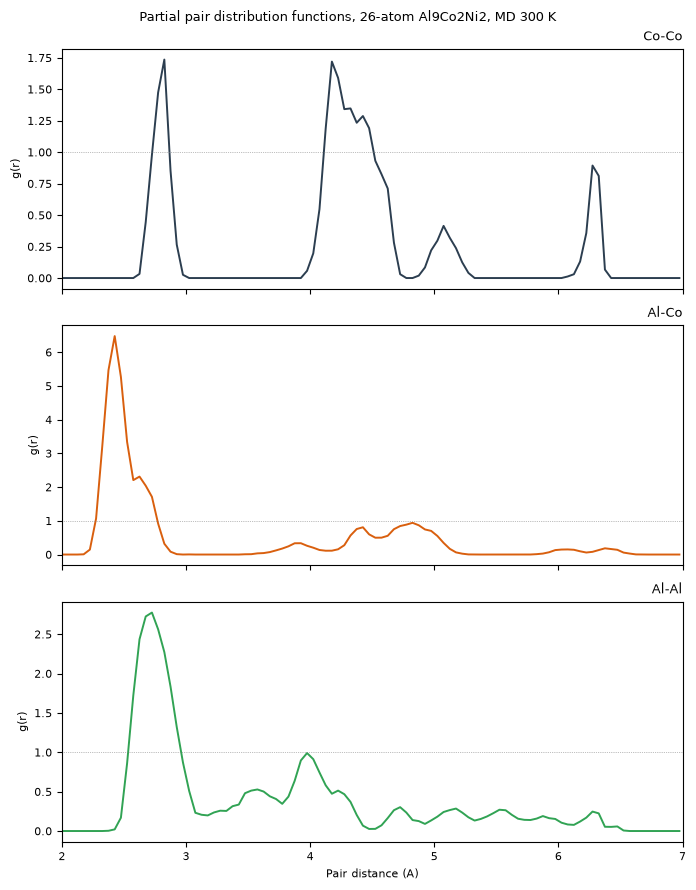

In [3]:
from ase.md.verlet import VelocityVerlet
import numpy as np, matplotlib.pyplot as plt, time

dyn_gr = VelocityVerlet(md_atoms, timestep)

# brief burn-in after thermostat removal (Albert's point), not recorded
print("NVE burn-in (1 ps)...")
dyn_gr.run(500)

# production storing POSITIONS
frames = []
def store_frame():
    frames.append(md_atoms.copy())
dyn_gr.attach(store_frame, interval=20)   # snapshot every 40 fs

print("NVE run storing positions for g(r)...")
t0 = time.time()
dyn_gr.run(4000)                          # 8 ps -> ~200 frames
print(f"Done in {time.time()-t0:.0f}s, {len(frames)} frames stored")

# --- partial g(r), averaged over frames ---
rmax, nbins = 7.0, 140
bins = np.linspace(0, rmax, nbins+1)
r = 0.5*(bins[1:]+bins[:-1])
shell_vol = 4/3*np.pi*(bins[1:]**3 - bins[:-1]**3)
V = md_atoms.get_volume()

pairs = [("Co","Co"), ("Al","Co"), ("Al","Al")]
colors = {"Co-Co":"#2c3e50", "Al-Co":"#d95f0e", "Al-Al":"#31a354"}

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for ax, (a, b) in zip(axes, pairs):
    hist = np.zeros(nbins)
    for f in frames:
        d = f.get_all_distances(mic=True)
        syms = np.array(f.get_chemical_symbols())
        ia, ib = np.where(syms==a)[0], np.where(syms==b)[0]
        dd = d[np.ix_(ia, ib)]
        dd = dd[dd > 0.1]
        hist += np.histogram(dd, bins=bins)[0]
    hist /= len(frames)
    # normalise to ideal gas -> proper g(r)
    na, nb = (np.array(md_atoms.get_chemical_symbols())==a).sum(), (np.array(md_atoms.get_chemical_symbols())==b).sum()
    norm = shell_vol * na * nb / V
    g = np.divide(hist, norm, out=np.zeros_like(hist), where=norm>0)
    ax.plot(r, g, color=colors[f"{a}-{b}"], lw=1.4)
    ax.axhline(1, color="gray", lw=0.5, ls=":")
    ax.set_ylabel("g(r)"); ax.set_title(f"{a}-{b}", loc="right")
    ax.set_xlim(2, 7)
axes[-1].set_xlabel("Pair distance (A)")
plt.suptitle("Partial pair distribution functions, 26-atom Al9Co2Ni2, MD 300 K")
plt.tight_layout()
plt.savefig("o2_gr_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
from scipy.signal import find_peaks

print("First-peak positions from your MD g(r) at 300 K:\n")
for (a, b) in [("Co","Co"), ("Al","Co"), ("Al","Al")]:
    hist = np.zeros(nbins)
    for f in frames:
        d = f.get_all_distances(mic=True)
        syms = np.array(f.get_chemical_symbols())
        ia, ib = np.where(syms==a)[0], np.where(syms==b)[0]
        dd = d[np.ix_(ia, ib)]
        dd = dd[dd > 0.1]
        hist += np.histogram(dd, bins=bins)[0]
    hist /= len(frames)
    na = (np.array(md_atoms.get_chemical_symbols())==a).sum()
    nb = (np.array(md_atoms.get_chemical_symbols())==b).sum()
    norm = shell_vol * na * nb / V
    g = np.divide(hist, norm, out=np.zeros_like(hist), where=norm>0)
    win = (r > 2.0) & (r < 3.5)          # first-neighbour window
    if g[win].max() > 0:
        first_peak = r[win][np.argmax(g[win])]
        print(f"{a}-{b}: first peak at {first_peak:.2f} A  (g = {g[win].max():.2f})")

First-peak positions from your MD g(r) at 300 K:

Co-Co: first peak at 2.83 A  (g = 1.74)
Al-Co: first peak at 2.43 A  (g = 6.48)
Al-Al: first peak at 2.73 A  (g = 2.77)


In [6]:
from ase.md.verlet import VelocityVerlet
import numpy as np, time

dyn_v = VelocityVerlet(md_atoms, timestep)

# short burn-in (already thermalised, but let it settle)
print("NVE burn-in (1 ps)...")
dyn_v.run(500)

velocities = []
energies = []
sample_every = 2
def record():
    velocities.append(md_atoms.get_velocities().copy())
    energies.append(md_atoms.get_total_energy())
dyn_v.attach(record, interval=sample_every)

print("NVE production storing velocities (10 ps)...")
t0 = time.time()
dyn_v.run(5000)
print(f"Done in {time.time()-t0:.0f}s")

velocities = np.array(velocities)
energies = np.array(energies)
print(f"Stored velocities: {velocities.shape}")
print(f"Energy drift: {(energies.max()-energies.min())/len(md_atoms)*1000:.3f} meV/atom")

NVE burn-in (1 ps)...
NVE production storing velocities (10 ps)...
Done in 1407s
Stored velocities: (2500, 26, 3)
Energy drift: 0.084 meV/atom


--- MD (300 K) element decomposition ---
Al: 60% of weight above 30 meV
Co: 34% of weight above 30 meV
Ni: 32% of weight above 30 meV


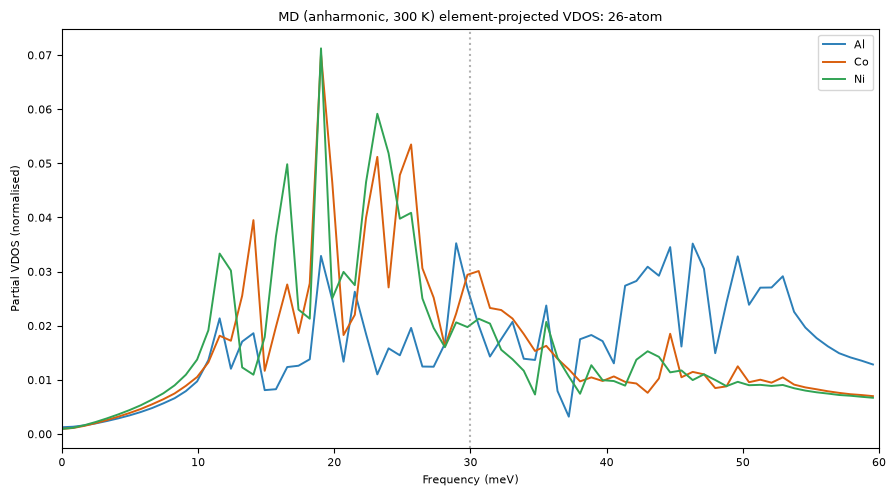

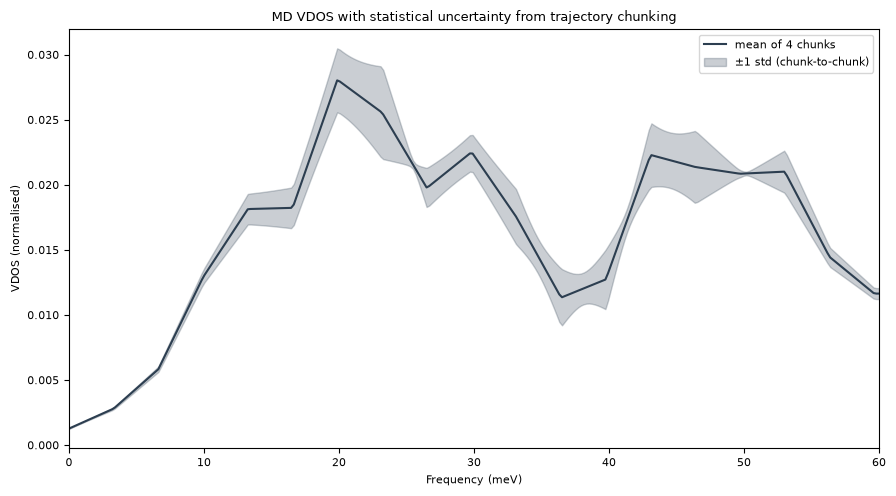


Mean relative uncertainty: 7%


In [7]:
import numpy as np, matplotlib.pyplot as plt
from ase.data import atomic_masses, atomic_numbers

syms = np.array(md_atoms.get_chemical_symbols())
masses = np.array([atomic_masses[atomic_numbers[s]] for s in syms])
n_samples = velocities.shape[0]
dt = sample_every * 2 * 1e-15

def vacf_to_vdos(vel, mass_sub, max_lag):
    vacf = np.zeros(max_lag)
    for lag in range(max_lag):
        dots = np.sum(vel[:vel.shape[0]-lag] * vel[lag:], axis=2) * mass_sub[None, :]
        vacf[lag] = dots.mean()
    vacf /= vacf[0]
    w = np.hanning(2*len(vacf))[len(vacf):]
    spec = np.abs(np.fft.rfft(vacf * w))
    f = np.fft.rfftfreq(len(vacf), d=dt) / 1e12 * 4.13567
    return f, spec

max_lag = n_samples // 2

# --- 1. ELEMENT-PROJECTED MD VDOS ---
fig, ax = plt.subplots(figsize=(9,5))
colors = {"Al":"#2c7fb8","Co":"#d95f0e","Ni":"#31a354"}
print("--- MD (300 K) element decomposition ---")
for el in ["Al","Co","Ni"]:
    idx = np.where(syms==el)[0]
    f, s = vacf_to_vdos(velocities[:, idx, :], masses[idx], max_lag)
    m = (f>=0)&(f<=60)
    s_n = s[m]/np.trapezoid(s[m], f[m])
    ax.plot(f[m], s_n, color=colors[el], lw=1.4, label=el)
    above30 = np.trapezoid(s_n[f[m]>30], f[m][f[m]>30])*100
    print(f"{el}: {above30:.0f}% of weight above 30 meV")
ax.axvline(30, color="gray", ls=":", alpha=0.6)
ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("Partial VDOS (normalised)")
ax.set_title("MD (anharmonic, 300 K) element-projected VDOS: 26-atom")
ax.set_xlim(0,60); ax.legend()
plt.tight_layout(); plt.savefig("o2_md_partial_vdos_26atom.png", dpi=150, bbox_inches="tight"); plt.show()

# --- 2. STATISTICAL UNCERTAINTY (chunk-to-chunk) ---
n_chunks = 4
chunk_len = n_samples // n_chunks
chunk_specs = []
fgrid = np.linspace(0, 60, 300)
for c in range(n_chunks):
    vel_c = velocities[c*chunk_len:(c+1)*chunk_len]
    f, s = vacf_to_vdos(vel_c, masses, chunk_len//2)
    m = (f>=0)&(f<=60)
    chunk_specs.append(np.interp(fgrid, f[m], s[m]/np.trapezoid(s[m], f[m])))
chunk_specs = np.array(chunk_specs)
mean, std = chunk_specs.mean(axis=0), chunk_specs.std(axis=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(fgrid, mean, color="#2c3e50", lw=1.5, label=f"mean of {n_chunks} chunks")
ax.fill_between(fgrid, mean-std, mean+std, color="#2c3e50", alpha=0.25, label="±1 std (chunk-to-chunk)")
ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("MD VDOS with statistical uncertainty from trajectory chunking")
ax.set_xlim(0,60); ax.legend()
plt.tight_layout(); plt.savefig("o2_md_vdos_uncertainty_26atom.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"\nMean relative uncertainty: {(std/np.maximum(mean,1e-12)).mean()*100:.0f}%")

In [8]:
import numpy as np, time
from ase.build import make_supercell
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units

# 2x2x2 supercell of the relaxed 26-atom structure
sc = make_supercell(atoms, np.diag([2,2,2]))
sc.calc = calc
print(f"Supercell: {len(sc)} atoms")

T = 300
MaxwellBoltzmannDistribution(sc, temperature_K=T)
Stationary(sc)
timestep = 2.0 * units.fs

def log(msg):
    print(msg)
    with open("md_progress.txt", "a") as f:
        f.write(msg + "\n")

log(f"=== MD run started: {len(sc)} atoms, {T} K ===")

# --- NVT equilibration (5 ps) ---
log("NVT equilibration (5 ps)...")
t0 = time.time()
Langevin(sc, timestep, temperature_K=T, friction=0.01/units.fs).run(2500)
log(f"  equilibration done in {time.time()-t0:.0f}s, T = {sc.get_kinetic_energy()/len(sc)/(1.5*units.kB):.0f} K")

# --- NVE burn-in (1 ps, not recorded) ---
dyn = VelocityVerlet(sc, timestep)
log("NVE burn-in (1 ps)...")
dyn.run(500)

# --- NVE production ---
velocities, energies = [], []
sample_every = 2
def record():
    velocities.append(sc.get_velocities().copy())
    energies.append(sc.get_total_energy())
dyn.attach(record, interval=sample_every)

n_steps = 15000          # 30 ps
n_blocks = 30            # update every ~20 min
log(f"NVE production: {n_steps*2/1000:.0f} ps on {len(sc)} atoms, {n_blocks} blocks...")
t0 = time.time()
for b in range(n_blocks):
    dyn.run(n_steps // n_blocks)
    el = time.time() - t0
    np.save("o2_md_supercell_velocities.npy", np.array(velocities))
    np.save("o2_md_supercell_energies.npy", np.array(energies))
    log(f"  block {b+1}/{n_blocks} | {el/60:.0f} min elapsed | ~{el/(b+1)*(n_blocks-1-b)/60:.0f} min left | {len(velocities)} samples")

velocities = np.array(velocities)
energies = np.array(energies)
log(f"FINISHED. Velocities: {velocities.shape}")
log(f"Energy drift: {(energies.max()-energies.min())/len(sc)*1000:.3f} meV/atom")

Supercell: 208 atoms
=== MD run started: 208 atoms, 300 K ===
NVT equilibration (5 ps)...
  equilibration done in 5336s, T = 318 K
NVE burn-in (1 ps)...
NVE production: 30 ps on 208 atoms, 30 blocks...
  block 1/30 | 18 min elapsed | ~525 min left | 250 samples
  block 2/30 | 35 min elapsed | ~486 min left | 500 samples
  block 3/30 | 51 min elapsed | ~462 min left | 750 samples
  block 4/30 | 71 min elapsed | ~459 min left | 1000 samples
  block 5/30 | 91 min elapsed | ~453 min left | 1250 samples
  block 6/30 | 111 min elapsed | ~446 min left | 1500 samples
  block 7/30 | 127 min elapsed | ~419 min left | 1750 samples
  block 8/30 | 144 min elapsed | ~395 min left | 2000 samples
  block 9/30 | 160 min elapsed | ~373 min left | 2250 samples
  block 10/30 | 179 min elapsed | ~358 min left | 2500 samples
  block 11/30 | 195 min elapsed | ~338 min left | 2750 samples
  block 12/30 | 212 min elapsed | ~318 min left | 3000 samples
  block 13/30 | 228 min elapsed | ~298 min left | 3250 samp

7500 samples, 208 atoms
Composition: {np.str_('Al'): np.int64(144), np.str_('Co'): np.int64(40), np.str_('Ni'): np.int64(24)}
Frequency resolution: 0.276 meV


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_29375/1329611399.py:34: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  hd = ph.get_total_dos_dict()



--- MD element decomposition (208-atom, 30 ps) ---
Al: 63% of weight above 30 meV   (144 atoms)
Co: 40% of weight above 30 meV   (40 atoms)
Ni: 34% of weight above 30 meV   (24 atoms)


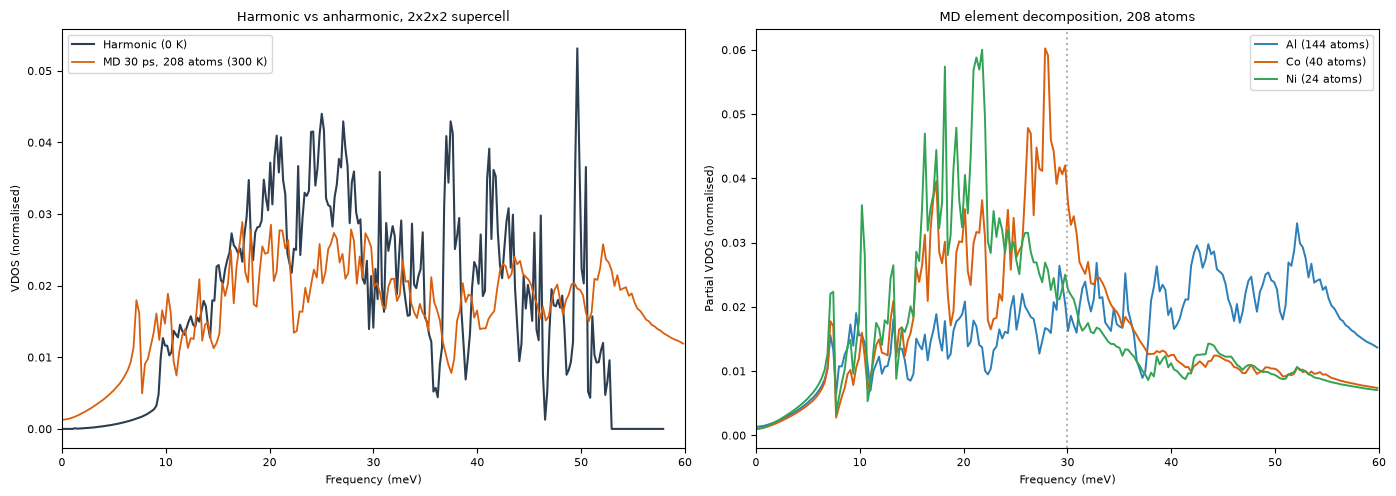

In [9]:
import numpy as np, matplotlib.pyplot as plt
from ase.data import atomic_masses, atomic_numbers
import phonopy

velocities = np.load("o2_md_supercell_velocities.npy")
syms = np.array(sc.get_chemical_symbols())
masses = np.array([atomic_masses[atomic_numbers[s]] for s in syms])
n_samples = velocities.shape[0]
dt = 4e-15                      # sampled every 4 fs
print(f"{n_samples} samples, {len(sc)} atoms")
print(f"Composition: {dict(zip(*np.unique(syms, return_counts=True)))}")

def vacf_to_vdos(vel, mass_sub, max_lag):
    vacf = np.zeros(max_lag)
    for lag in range(max_lag):
        dots = np.sum(vel[:vel.shape[0]-lag] * vel[lag:], axis=2) * mass_sub[None, :]
        vacf[lag] = dots.mean()
    vacf /= vacf[0]
    w = np.hanning(2*len(vacf))[len(vacf):]
    spec = np.abs(np.fft.rfft(vacf * w))
    f = np.fft.rfftfreq(len(vacf), d=dt) / 1e12 * 4.13567
    return f, spec

max_lag = n_samples // 2
f_md, s_md = vacf_to_vdos(velocities, masses, max_lag)
m = (f_md >= 0) & (f_md <= 60)
f_md, s_md = f_md[m], s_md[m]
s_md /= np.trapezoid(s_md, f_md)
print(f"Frequency resolution: {f_md[1]-f_md[0]:.3f} meV")

# harmonic for comparison
ph = phonopy.load("o2_phonon_26atom.yaml")
ph.run_mesh([20,20,20]); ph.run_total_dos(freq_pitch=0.05)
hd = ph.get_total_dos_dict()
h_f = hd["frequency_points"] * 4.13567
h_d = hd["total_dos"]
pos = h_f >= 0
h_dn = h_d[pos] / np.trapezoid(h_d[pos], h_f[pos])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: harmonic vs MD
axes[0].plot(h_f[pos], h_dn, color="#2c3e50", lw=1.5, label="Harmonic (0 K)")
axes[0].plot(f_md, s_md, color="#d95f0e", lw=1.3, label="MD 30 ps, 208 atoms (300 K)")
axes[0].set_xlim(0,60); axes[0].legend()
axes[0].set_xlabel("Frequency (meV)"); axes[0].set_ylabel("VDOS (normalised)")
axes[0].set_title("Harmonic vs anharmonic, 2x2x2 supercell")

# right: element decomposition
colors = {"Al":"#2c7fb8","Co":"#d95f0e","Ni":"#31a354"}
print("\n--- MD element decomposition (208-atom, 30 ps) ---")
for el in ["Al","Co","Ni"]:
    idx = np.where(syms==el)[0]
    fe, se = vacf_to_vdos(velocities[:, idx, :], masses[idx], max_lag)
    me = (fe>=0)&(fe<=60)
    sen = se[me]/np.trapezoid(se[me], fe[me])
    axes[1].plot(fe[me], sen, color=colors[el], lw=1.4, label=f"{el} ({len(idx)} atoms)")
    above30 = np.trapezoid(sen[fe[me]>30], fe[me][fe[me]>30])*100
    print(f"{el}: {above30:.0f}% of weight above 30 meV   ({len(idx)} atoms)")
axes[1].axvline(30, color="gray", ls=":", alpha=0.6)
axes[1].set_xlim(0,60); axes[1].legend()
axes[1].set_xlabel("Frequency (meV)"); axes[1].set_ylabel("Partial VDOS (normalised)")
axes[1].set_title("MD element decomposition, 208 atoms")

plt.tight_layout()
plt.savefig("o2_md_supercell_vdos.png", dpi=150, bbox_inches="tight")
plt.show()

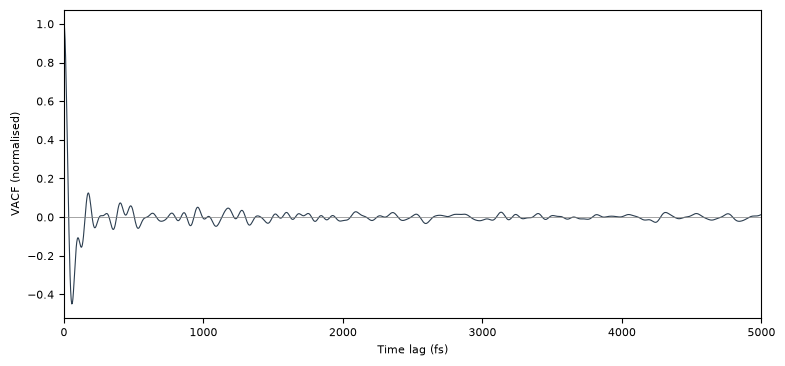

VACF at max lag: -0.0052
|VACF| mean over last 25% of lags: 0.0103


In [10]:
vacf = np.zeros(max_lag)
for lag in range(max_lag):
    dots = np.sum(velocities[:n_samples-lag] * velocities[lag:], axis=2) * masses[None, :]
    vacf[lag] = dots.mean()
vacf /= vacf[0]

t_fs = np.arange(max_lag) * 4
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, vacf, lw=0.8, color="#2c3e50")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Time lag (fs)"); ax.set_ylabel("VACF (normalised)")
ax.set_xlim(0, 5000)
plt.show()

print(f"VACF at max lag: {vacf[-1]:.4f}")
print(f"|VACF| mean over last 25% of lags: {np.abs(vacf[int(0.75*max_lag):]).mean():.4f}")

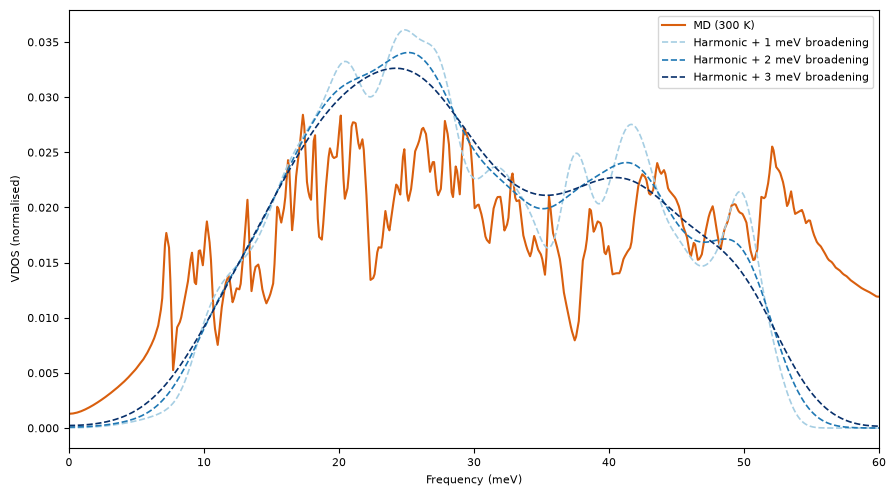

In [11]:
from scipy.ndimage import gaussian_filter1d

h_grid = np.linspace(0, 60, 600)
h_interp = np.interp(h_grid, h_f[pos], h_dn)
md_interp = np.interp(h_grid, f_md, s_md)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(h_grid, md_interp, color="#d95f0e", lw=1.5, label="MD (300 K)")
for sig, c in [(1.0,"#a6cee3"), (2.0,"#1f78b4"), (3.0,"#08306b")]:
    b = gaussian_filter1d(h_interp, sig/(h_grid[1]-h_grid[0]))
    b /= np.trapezoid(b, h_grid)
    ax.plot(h_grid, b, color=c, lw=1.2, ls="--", label=f"Harmonic + {sig:.0f} meV broadening")
ax.set_xlim(0,60); ax.legend(); ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("VDOS (normalised)")
plt.tight_layout(); plt.show()

7500 samples, 208 atoms
Frequency resolution: 0.138 meV
VDOS at 60 meV: 0.00071  (should be ~0 if the tail was the bug)


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_29375/4273783307.py:38: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  hd = ph.get_total_dos_dict()



--- MD element decomposition (208-atom, 30 ps) ---
Al: 60% of weight above 30 meV   (144 atoms)
Co: 16% of weight above 30 meV   (40 atoms)
Ni: 15% of weight above 30 meV   (24 atoms)


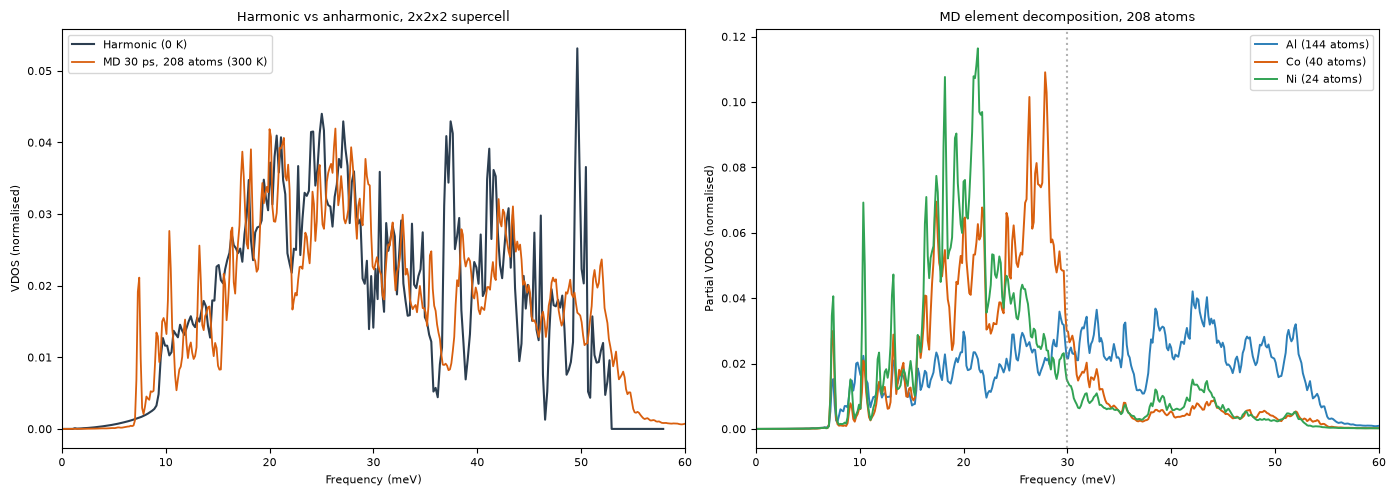

In [12]:
import numpy as np, matplotlib.pyplot as plt
from ase.data import atomic_masses, atomic_numbers
import phonopy

velocities = np.load("o2_md_supercell_velocities.npy")
syms = np.array(sc.get_chemical_symbols())
masses = np.array([atomic_masses[atomic_numbers[s]] for s in syms])
n_samples = velocities.shape[0]
dt = 4e-15
print(f"{n_samples} samples, {len(sc)} atoms")

def vacf_to_vdos(vel, mass_sub, max_lag):
    vacf = np.zeros(max_lag)
    for lag in range(max_lag):
        dots = np.sum(vel[:vel.shape[0]-lag] * vel[lag:], axis=2) * mass_sub[None, :]
        vacf[lag] = dots.mean()
    vacf /= vacf[0]
    w = np.hanning(2*len(vacf))[len(vacf):]
    vw = vacf * w
    # mirror to make the VACF even, then take the REAL part = cosine transform
    full = np.concatenate([vw, vw[-1:0:-1]])
    spec = np.real(np.fft.rfft(full))
    spec = np.maximum(spec, 0)
    f = np.fft.rfftfreq(len(full), d=dt) / 1e12 * 4.13567
    return f, spec

max_lag = n_samples // 2
f_md, s_md = vacf_to_vdos(velocities, masses, max_lag)
m = (f_md >= 0) & (f_md <= 60)
f_md, s_md = f_md[m], s_md[m]
s_md /= np.trapezoid(s_md, f_md)
print(f"Frequency resolution: {f_md[1]-f_md[0]:.3f} meV")
print(f"VDOS at 60 meV: {s_md[-1]:.5f}  (should be ~0 if the tail was the bug)")

# harmonic
ph = phonopy.load("o2_phonon_26atom.yaml")
ph.run_mesh([20,20,20]); ph.run_total_dos(freq_pitch=0.05)
hd = ph.get_total_dos_dict()
h_f = hd["frequency_points"] * 4.13567
h_d = hd["total_dos"]
pos = h_f >= 0
h_dn = h_d[pos] / np.trapezoid(h_d[pos], h_f[pos])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_f[pos], h_dn, color="#2c3e50", lw=1.5, label="Harmonic (0 K)")
axes[0].plot(f_md, s_md, color="#d95f0e", lw=1.3, label="MD 30 ps, 208 atoms (300 K)")
axes[0].set_xlim(0,60); axes[0].legend()
axes[0].set_xlabel("Frequency (meV)"); axes[0].set_ylabel("VDOS (normalised)")
axes[0].set_title("Harmonic vs anharmonic, 2x2x2 supercell")

colors = {"Al":"#2c7fb8","Co":"#d95f0e","Ni":"#31a354"}
print("\n--- MD element decomposition (208-atom, 30 ps) ---")
for el in ["Al","Co","Ni"]:
    idx = np.where(syms==el)[0]
    fe, se = vacf_to_vdos(velocities[:, idx, :], masses[idx], max_lag)
    me = (fe>=0)&(fe<=60)
    sen = se[me]/np.trapezoid(se[me], fe[me])
    axes[1].plot(fe[me], sen, color=colors[el], lw=1.4, label=f"{el} ({len(idx)} atoms)")
    above30 = np.trapezoid(sen[fe[me]>30], fe[me][fe[me]>30])*100
    print(f"{el}: {above30:.0f}% of weight above 30 meV   ({len(idx)} atoms)")
axes[1].axvline(30, color="gray", ls=":", alpha=0.6)
axes[1].set_xlim(0,60); axes[1].legend()
axes[1].set_xlabel("Frequency (meV)"); axes[1].set_ylabel("Partial VDOS (normalised)")
axes[1].set_title("MD element decomposition, 208 atoms")

plt.tight_layout()
plt.savefig("o2_md_supercell_vdos.png", dpi=150, bbox_inches="tight")
plt.show()